# Galaxies

Peter Ralph  
2026-03-09

# The Galaxy Zoo

[galaxyzoo.org](https://galaxyzoo.org)

> For more than 15 years, we’ve asked volunteers to help us explore
> galaxies near and far, sampling a fraction of the roughly one hundred
> billion that are scattered throughout the observable Universe. Each
> one of the systems, containing billions of stars, has had a unique
> life, interacting with its surroundings and with other galaxies in
> many different ways; the aim of the Galaxy Zoo team is to try and
> understand these processes, and to work out what galaxies can tell us
> about the past, present and future of the Universe as a whole.

next slide from [NASA/ESA/CSA James Webb Space
Telescope](https://esawebb.org/images/potm2504a/)

## 

## The Galaxy Zoo 1

https://data.galaxyzoo.org/

> The original Galaxy Zoo project ran from July 2007 until February
> 2009. It was replaced by Galaxy Zoo 2, Galaxy Zoo: Hubble, and Galaxy
> Zoo: CANDELS. In the original Galaxy Zoo project, volunteers
> classified images of Sloan Digital Sky Survey galaxies as belonging to
> one of six categories - elliptical, clockwise spiral, anticlockwise
> spiral, edge-on , star/don’t know, or merger.

## Data

-   nearly 900,000 images, each centered on a galaxy
-   each 424 x 424 (color) JPEG
-   I’m looking at only 5,000 of those images
-   … which is 2,696,640,000 values

**Goals**:

-   describe the color distribution among galaxies
-   see what PCA gives us

<figure>
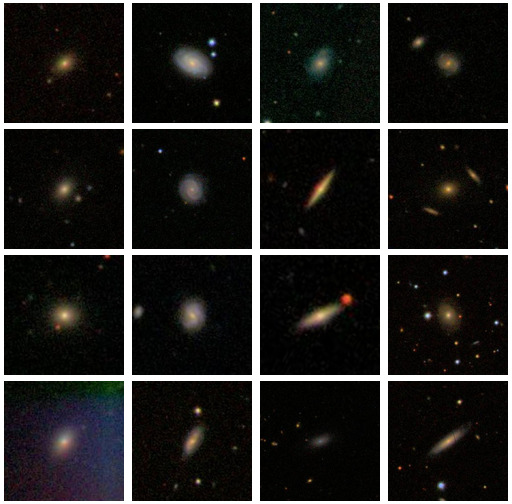
<figcaption aria-hidden="true">montage of 16 galaxies</figcaption>
</figure>

# Color distribution

We’ll use [HSV space](https://en.wikipedia.org/wiki/HSL_and_HSV):

-   `H`ue is circular (think rainbow)
-   `S`aturation is white -\> colorful
-   `V`alue is black -\> colorful

## Set-up

-   get the [zip
    file](https://github.com/UOdsci/ds435/blob/main/data/galaxies.zip)

In [ ]:
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import os, glob
import numpy as np
import pandas as pd
import plotnine as p9
import sklearn.decomposition
import colorsys

filenames = glob.glob("data/galaxies/*.jpg")

## By pixel

Let’s compare color values in the center to values near the edge:

In [ ]:
def get_pixel(filenames, i, j):
    out = pd.DataFrame(
            np.array([Image.open(fn).convert("HSV").getpixel((i, j)) for fn in filenames]),
            columns=("H", "S", "V"),
        )
    return out

pix0 = get_pixel(filenames, 212, 212)
pix1 = get_pixel(filenames, 0, 212)

## Value

In [ ]:
p9.ggplot(pix0, p9.aes(x='V')) + p9.geom_histogram(bins=32) |  p9.ggplot(pix1, p9.aes(x="V")) + p9.geom_histogram(bins=32)

## Saturation

In [ ]:
p9.ggplot(pix0, p9.aes(x='S')) + p9.geom_histogram(bins=32) |  p9.ggplot(pix1, p9.aes(x="S")) + p9.geom_histogram(bins=32)

## Hue

In [ ]:
p9.ggplot(pix0, p9.aes(x='H')) + p9.geom_histogram(bins=32) |  p9.ggplot(pix1, p9.aes(x="H")) + p9.geom_histogram(bins=32)

## Image-wide averages

Next, the average value across the image:

In [ ]:
RGB = pd.DataFrame(
    np.array([np.asarray(Image.open(fn)).mean(axis=(0,1)) for fn in filenames]),
    columns=("R", "G", "B"),
)
HSV = pd.DataFrame(
    np.array([np.asarray(Image.open(fn).convert("HSV")).mean(axis=(0,1)) for fn in filenames]),
    columns=("H", "S", "V"),
)
colors = pd.concat([RGB, HSV], axis=1)

In [ ]:
p9.ggplot(colors, p9.aes(x="R", y="G", color='B')) + p9.geom_point() + p9.scale_color_continuous('Blues')

## Extremes

In [ ]:
def plot_extremes(filenames, x, n=3):
    fig, axes = plt.subplots(2, n)
    ix = np.argsort(x)
    for ax, k in zip(axes[0], ix[:n]):
        ax.imshow(Image.open(filenames[k]))
        ax.set_title(f"{k}: {x[k]:.2f}")
        ax.set_axis_off()
    for ax, k in zip(axes[1], ix[-n:]):
        ax.imshow(Image.open(filenames[k]))
        ax.set_title(f"{k}: {x[k]:.2f}")
        ax.set_axis_off();

## Most blue:

In [ ]:
plot_extremes(filenames, colors['B'])

## Most red:

In [ ]:
plot_extremes(filenames, colors['R'])

## Image-wide average, in HSV

In [ ]:
p9.ggplot(colors, p9.aes(x="H", y="V", color='S')) + p9.geom_point() + p9.scale_color_continuous('gray')

## Most V

In [ ]:
plot_extremes(filenames, colors['V'])

## Most H

In [ ]:
plot_extremes(filenames, colors['H'])

# PCA, in RGB space

In [ ]:
def im_to_array(fn, size):
    im = Image.open(fn).resize(size=size)
    return np.array([np.asarray(x) for x in im.split()]).flatten()
    
def images_to_array(filenames, size):
    return np.array([im_to_array(fn, size=size) for fn in filenames])

size = (100, 110)
X = images_to_array(filenames, size=size).astype("float")
X -= X.mean(axis=1)[:,np.newaxis]
X.shape

##

In [ ]:
pca = sklearn.decomposition.PCA(n_components=12).fit(X)
pcs = pd.DataFrame(
    pca.transform(X), columns=[f"PC{k+1}" for k in range(pca.n_components_)]
)
ij = pd.Series([f"{x}.{i}.{j}" for x in ('r', 'g', 'b') for i in range(size[0]) for j in range(size[1])])
loadings = pd.concat([
    pd.DataFrame(pca.components_.T, index=ij, columns=[f"PC{k+1}" for k in range(pca.n_components_)])
        .reset_index(names='variable'),
    pd.DataFrame.from_records(ij.str.split("."), columns=('rgb', 'row', 'col')),
], axis=1)
loadings['row'] = loadings['row'].astype('int')
loadings['col'] = loadings['col'].astype('int')
loadings

## What are the loadings?

In [ ]:
(
    loadings
    >>
    p9.ggplot(p9.aes(x='row', y='PC1', color='factor(col)'))
    + p9.geom_line()
    + p9.facet_grid(rows='rgb')
    + p9.scale_color_discrete(guide=None)
) + p9.theme(figure_size=(12,12))

##

In [ ]:
(
    loadings
    .query("col.isin((0, 24, 49, 74, 99))")
    >>
    p9.ggplot(p9.aes(x='row', y='PC1', color='factor(col)'))
    + p9.geom_line()
    + p9.facet_grid(rows='rgb')
    + p9.scale_color_discrete(guide=None)
) + p9.theme(figure_size=(12,12))

## Another way to look at the loadings

In [ ]:
def get_pc_image(loadings, k):
    pc_im = np.array([
        loadings.query(f"rgb == '{x}'")[f'PC{k}'].values.reshape((size[1], size[0]))
        for x in "rgb"
    ])
    pc_im -= pc_im.min()
    pc_im *= 255 / (pc_im.max() - pc_im.min())
    pc_im = pc_im.astype("int")
    return np.moveaxis(pc_im, [0,1,2], [2,1,0])

## PCs 1-3

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k, ax in zip(range(1,4), axes):
    ax.imshow(get_pc_image(loadings, k))
    ax.set_title(f"PC{k}");

## PCs 4-6

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k, ax in zip(range(4,7), axes):
    ax.imshow(get_pc_image(loadings, k))
    ax.set_title(f"PC{k}");

## PC1

In [ ]:
plot_extremes(filenames, pcs['PC1'])

## PC2

In [ ]:
plot_extremes(filenames, pcs['PC2'])

## PC3

In [ ]:
plot_extremes(filenames, pcs['PC3'])

## PC4

In [ ]:
plot_extremes(filenames, pcs['PC4'])